In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

cohort_summary = pd.read_csv('../data/processed/cohort_summary.csv', index_col='listing_year')
bootstrap_summary = pd.read_csv('../data/processed/bootstrap_summary.csv')
winners_pivot = pd.read_csv('../data/processed/winners_pivot.csv', index_col='listing_year')
correlation_pivot = pd.read_csv('../data/processed/pop_correlation_summary.csv', index_col='factor')
summary_table = pd.read_csv('../data/processed/factor_comparison_summary.csv', index_col='factor')
df = pd.read_csv('../data/processed/ipo_master_returns.csv')
ipo_clean = pd.read_csv('../data/processed/ipo_clean.csv')

merge_cols = ['nse_symbol', 'issue_size_crores', 'QIB', 'HNI', 'RII', 'Total']
df = df.merge(ipo_clean[merge_cols], on='nse_symbol', how='left')

In [2]:
horizon_cols = ['relative_cagr_6mo', 'relative_cagr_1yr', 'relative_cagr_2yr', 'relative_cagr_3yr']

horizon_cutoff_year = {
    'relative_cagr_6mo': 2025,
    'relative_cagr_1yr': 2024,
    'relative_cagr_2yr': 2023,
    'relative_cagr_3yr': 2022,
}

def mature_subset(df, horizon_col):
    max_year = horizon_cutoff_year[horizon_col]
    return df[df['listing_year'] <= max_year]

In [3]:
# Consistent style setup for all visuals
PALETTE = {
    'highlight': '#c0392b',   # red — for statistically significant / high-hype findings
    'neutral': '#3498db',     # blue — normal/baseline
    'muted': '#95a5a6',       # gray — secondary/context
    'text_dark': '#2c3e50',
}

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

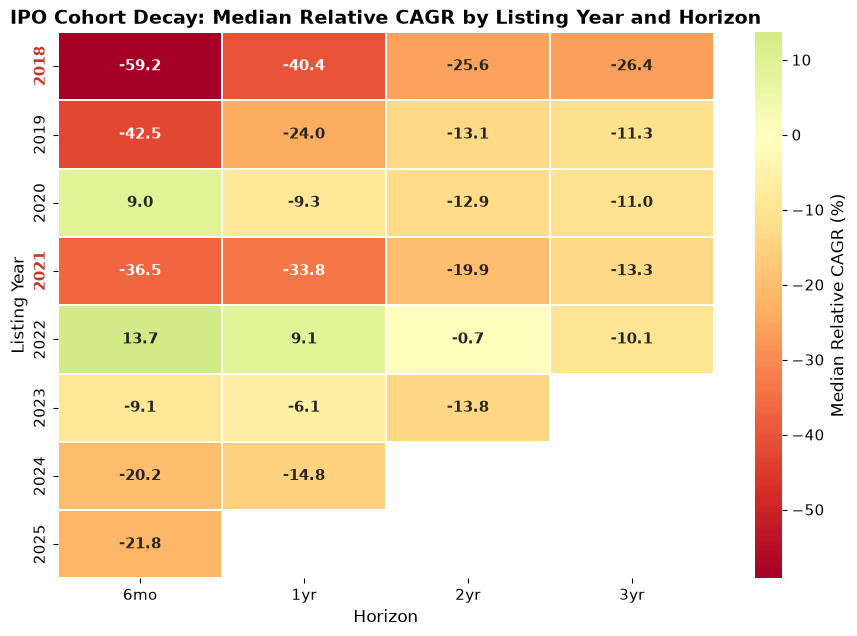

In [4]:
cohort_summary_display = cohort_summary.copy()
cohort_summary_display.columns = ['6mo', '1yr', '2yr', '3yr']

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(
    cohort_summary_display,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=1.2,
    linecolor='white',
    annot_kws={'fontsize': 11, 'fontweight': 'bold'},
    cbar_kws={'label': 'Median Relative CAGR (%)'},
    ax=ax
)

for label in ax.get_yticklabels():
    if label.get_text() in ('2018', '2021'):
        label.set_fontweight('bold')
        label.set_color(PALETTE['highlight'])

ax.set_title('IPO Cohort Decay: Median Relative CAGR by Listing Year and Horizon')
ax.set_xlabel('Horizon')
ax.set_ylabel('Listing Year')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('../reports/heatmap_cohort_decay.png', dpi=200, bbox_inches='tight')
plt.show()

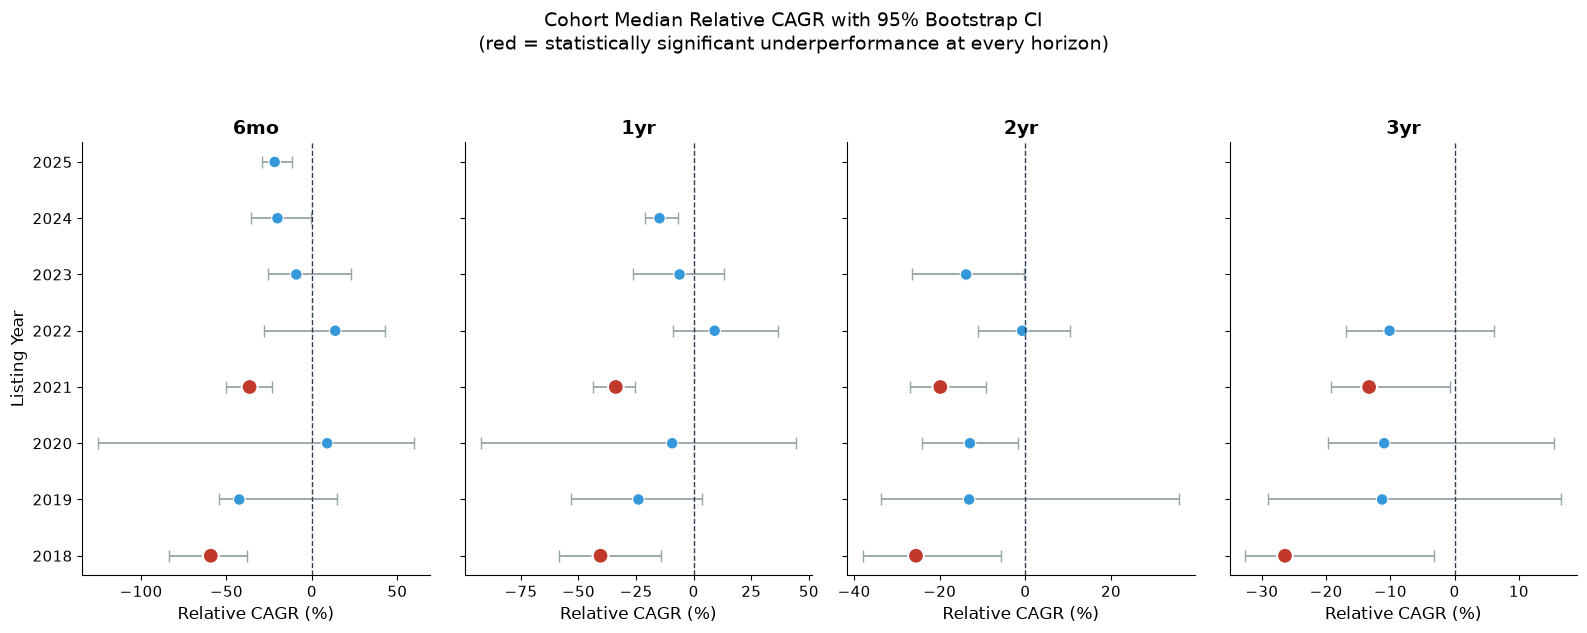

In [5]:
significant_years = {2018, 2021}

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)

for ax, horizon in zip(axes, horizon_cols):
    sub = bootstrap_summary[bootstrap_summary['horizon'] == horizon].sort_values('listing_year')

    colors = [PALETTE['highlight'] if y in significant_years else PALETTE['neutral'] for y in sub['listing_year']]
    sizes = [130 if y in significant_years else 70 for y in sub['listing_year']]
    edge_widths = [1.5 if y in significant_years else 0.8 for y in sub['listing_year']]

    ax.errorbar(
        sub['median'], sub['listing_year'],
        xerr=[sub['median'] - sub['ci_low'], sub['ci_high'] - sub['median']],
        fmt='none', ecolor=PALETTE['muted'], capsize=4, zorder=1, linewidth=1.3
    )
    ax.scatter(
        sub['median'], sub['listing_year'],
        color=colors, s=sizes, zorder=2,
        edgecolor='white', linewidth=edge_widths
    )
    ax.axvline(0, color=PALETTE['text_dark'], linestyle='--', linewidth=1)
    ax.set_title(horizon.replace('relative_cagr_', ''))
    ax.set_xlabel('Relative CAGR (%)')

axes[0].set_ylabel('Listing Year')
fig.suptitle('Cohort Median Relative CAGR with 95% Bootstrap CI\n(red = statistically significant underperformance at every horizon)', y=1.05, fontsize=14)
plt.tight_layout()

plt.savefig('../reports/forest_plot_cohort_ci.png', dpi=200, bbox_inches='tight')
plt.show()

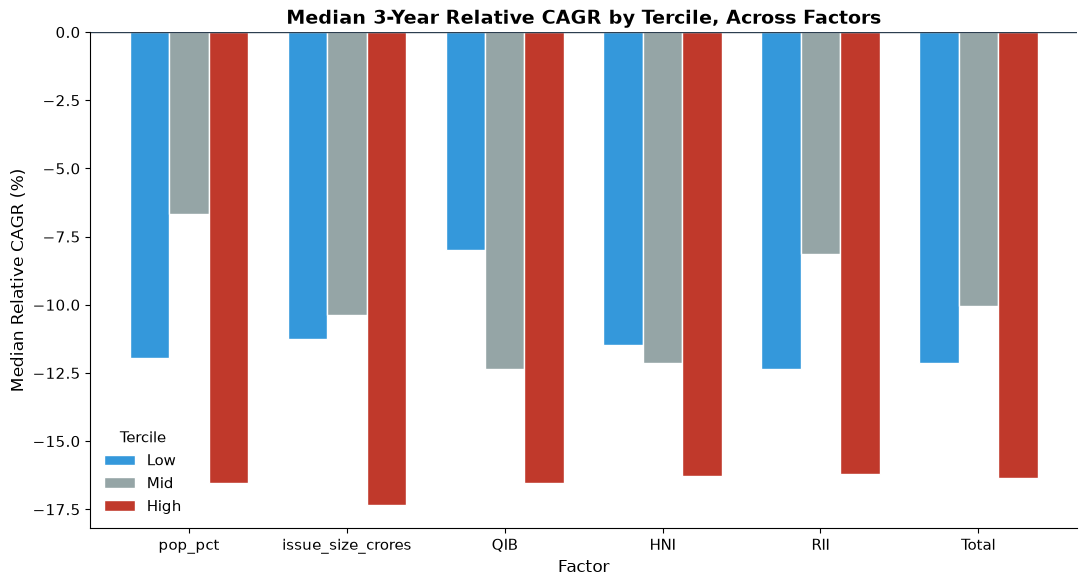

In [6]:
all_factors = ['pop_pct', 'issue_size_crores', 'QIB', 'HNI', 'RII', 'Total']

tercile_data = {}
for factor in all_factors:
    sub = mature_subset(df, 'relative_cagr_3yr')[[factor, 'relative_cagr_3yr']].dropna()
    sub['tercile'] = pd.qcut(sub[factor], q=3, labels=['Low', 'Mid', 'High'])
    tercile_data[factor] = sub.groupby('tercile')['relative_cagr_3yr'].median()

tercile_df = pd.DataFrame(tercile_data)

fig, ax = plt.subplots(figsize=(11, 6))
tercile_df.T.plot(
    kind='bar', ax=ax,
    color=[PALETTE['neutral'], PALETTE['muted'], PALETTE['highlight']],
    edgecolor='white', width=0.75
)

ax.axhline(0, color=PALETTE['text_dark'], linewidth=1)
ax.set_title('Median 3-Year Relative CAGR by Tercile, Across Factors')
ax.set_xlabel('Factor')
ax.set_ylabel('Median Relative CAGR (%)')
ax.legend(title='Tercile', frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('../reports/tercile_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

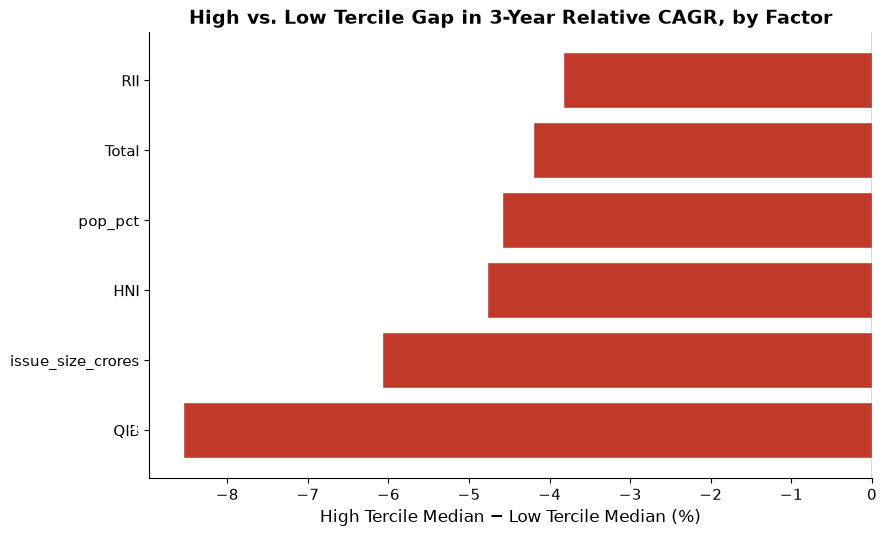

In [7]:
plot_data = summary_table.sort_values('tercile_gap_high_minus_low_3yr')

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(
    plot_data.index, plot_data['tercile_gap_high_minus_low_3yr'],
    color=PALETTE['highlight'], edgecolor='white'
)

ax.axvline(0, color=PALETTE['text_dark'], linewidth=1)
ax.set_title('High vs. Low Tercile Gap in 3-Year Relative CAGR, by Factor')
ax.set_xlabel('High Tercile Median − Low Tercile Median (%)')
ax.set_ylabel('')

for bar, value in zip(bars, plot_data['tercile_gap_high_minus_low_3yr']):
    ax.text(value - 0.3, bar.get_y() + bar.get_height() / 2, f'{value:.1f}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/factor_comparison_gap.png', dpi=200, bbox_inches='tight')
plt.show()